Lab 2: Predictive Analytics with Machine Learning
Duration: 2 weeks [18 Jun - 25 Jun, 2026] Due Date: 25th June, 2026 Format: Jupyter Notebook / Google Colab Grading: This is a graded lab.

Student Name: Nii Sowah Kwabla Sowah Student ID: 18682028

Objective
In this lab you will run a complete machine-learning workflow on two real tabular datasets, covering both supervised and unsupervised learning:

#	Task	Dataset	Type	Target
1	Regression	NYC Yellow Taxi trips	Supervised	tip_amount (continuous)
2	Multi-class classification	Obesity-level prediction	Supervised	NObeyesdad (7 classes)
3	Clustering (K-Means)	Obesity features (labels hidden)	Unsupervised	discover patient groups
Along the way you will practise NumPy, Pandas, and scikit-learn to load and explore data, clean and preprocess it, engineer features, split it into train / validation / test sets, train models, check for overfitting, and discover hidden structure with clustering.

Note: In this lab your reasoning is graded just as heavily as your code. Every section ends with a Student Reasoning box — fill it in with full sentences that justify your choices.

Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering), feature engineering, train/validation/test splits, model evaluation, and overfitting.


Part 0: Repository Setup (done outside this notebook)

Create a public repository named lab-2-predictive-analytics on GitHub/GitLab.
Clone it locally (or link it to Google Colab).
Save this notebook inside the repo as lab_2_predictive_analytics.ipynb.
Add a requirements.txt (provided with this lab) listing: numpy pandas scikit-learn matplotlib seaborn.
Commit and push your finished, fully-run notebook at the end.

Local setup

python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
Open a new notebook, rename it, and run the cells below directly (the datasets are loaded straight from their URLs, so no Drive mount is required).

In [25]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Section 1 — Supervised Learning: Regression
Predicting taxi tip_amount (NYC Yellow Taxi)
Each row is a completed taxi trip. Your goal is to predict the tip a passenger leaves (tip_amount, a continuous value) from the trip's characteristics. The available columns are:

VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount

Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


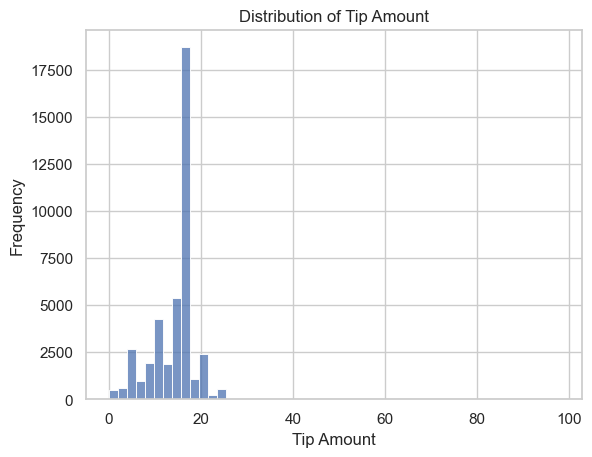

In [15]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
taxi.shape, taxi.head(), taxi.info(), taxi.describe(), taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(data=taxi,x="tip_amount", bins = 50)
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amount')
plt.show()

Student Reasoning — Taxi data exploration What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

Answer: Within the dataset, there are 41202 rows and 13 columns. There are no missing values in the dataset. The tip_amount distribution is right-skewed. This suggests that most of the tips are small, with a few large tips. the presence of many zeros indicates that many passengers did not leave a tip. This will influence preprocessing by potentially requiring transformations to handle the zero values and skewness. We may also need to consider outlier detection and removal to improve model performance.

Part 1.2 — Preprocessing & feature engineering

Clean the data and create features that help predict the tip.

In [16]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi = taxi.dropna()

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
taxi =pd.get_dummies(taxi, columns = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag'], drop_first = True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

Student Reasoning — Taxi preprocessing 1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

Answer: I handled missing/invalid rows by removing any rows with negative tips or zero distance trips, as there is no valid reason for these values to exist in the dataset. I engineered new features such as fare_per_mile (fare_amount divided by trip_distance) to capture the cost efficiency of the trip. I chose StandardScaler for scaling because it standardizes the features by removing the mean and scaling to unit variance, which is appropriate for algorithms that assume normally distributed data.

Part 1.3 — Train / Validation / Test split

A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [17]:
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns = ['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state = RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = RANDOM_STATE)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)
x_val_scaled = scaler.transform(X_val)

Student Reasoning — Splitting What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

Answer: I used a 60/20/20 split for train/validation/test sets. A separate validation set is useful because it allows us to tune parameters and select the best model without contaminating the test set. The scaler and imputation statistics must be fit on the training data only to prevent data leakage, ensuring that the model's performance is evaluated on truly unseen data.

Part 1.4 — Train a regressor and check for overfitting

Train a model and evaluate it on train, validation, and test sets.

LinearRegression - Train RMSE: 4.8173, R^2: 0.0488
LinearRegression - Validation RMSE: 4.7795, R^2: 0.0689
LinearRegression - Test RMSE: 5.2236, R^2: 0.0402
RandomForestRegressor - Train RMSE: 2.8253, R^2: 0.6728
RandomForestRegressor - Validation RMSE: 5.4365, R^2: -0.2047
RandomForestRegressor - Test RMSE: 5.8185, R^2: -0.1908


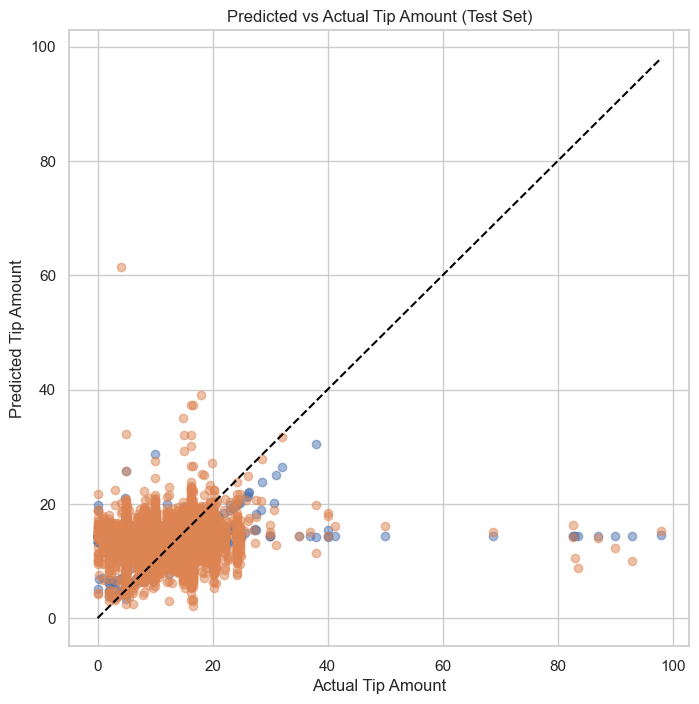

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
Models ={'LinearRegression': LinearRegression(), 'RandomForestRegressor': RandomForestRegressor(random_state=RANDOM_STATE)}

# TODO: Predict on train, validation, and test sets.
results = {}
for name, model in Models.items():
    model.fit(x_train_scaled, y_train)
    y_train_pred = model.predict(x_train_scaled)
    y_val_pred = model.predict(x_val_scaled)
    y_test_pred = model.predict(x_test_scaled)

    # TODO: Report RMSE and R^2 for ALL THREE sets.
    #   from sklearn.metrics import mean_squared_error, r2_score
    #   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
    results[name] = {
        'train': (mean_squared_error(y_train, y_train_pred) ** 0.5, r2_score(y_train, y_train_pred)),
        'validation': (mean_squared_error(y_val, y_val_pred) ** 0.5, r2_score(y_val, y_val_pred)),
        'test': (mean_squared_error(y_test, y_test_pred) ** 0.5, r2_score(y_test, y_test_pred))
    }
    results[name]['test_predictions'] = y_test_pred
    print(f"{name} - Train RMSE: {results[name]['train'][0]:.4f}, R^2: {results[name]['train'][1]:.4f}")
    print(f"{name} - Validation RMSE: {results[name]['validation'][0]:.4f}, R^2: {results[name]['validation'][1]:.4f}")
    print(f"{name} - Test RMSE: {results[name]['test'][0]:.4f}, R^2: {results[name]['test'][1]:.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 8))
for name in Models.keys():
    plt.scatter(y_test, results[name]['test_predictions'], alpha=0.5, label=name)
plt.plot([0, max(y_test)], [0, max(y_test)], color='black', linestyle='--', label='y=x')
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Predicted vs Actual Tip Amount (Test Set)')
plt.show()

Student Reasoning — Regression evaluation & overfitting 1. Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

Answer: Linear Regression performed most consistently across splits (R² of 0.049/0.069/0.040), though its predictive power is weak overall. This points to underfitting, since the model can't capture the relationship well even on training data. Random Forest severely overfit: it achieved R²=0.673 on train but collapsed to R²=-0.205 on validation and R²=-0.191 on test, meaning its predictions were worse than a naive mean baseline on unseen data. To fix this I would reduce max_depth, increase min_samples_leaf, or tune via cross-validation

Section 2 — Supervised Learning: Multi-class Classification

Predicting obesity level (NObeyesdad)

Each row describes a person's eating habits and physical condition. Predict their obesity category NObeyesdad, which has 7 classes: Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III.

Feature columns: Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS.

Part 2.1 — Load and explore the obesity data

Look at the shape, dtypes, missing values, and especially the class balance of the target.

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

<Axes: xlabel='NObeyesdad', ylabel='count'>

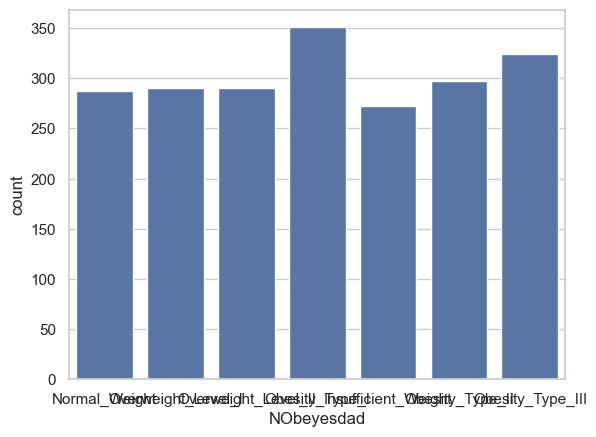

In [19]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity =pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
print(obesity.head())
print(obesity.info())
print(obesity.describe())
print(obesity.isnull().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
obesity.value_counts('NObeyesdad')
sns.countplot(data=obesity, x='NObeyesdad')

Student Reasoning — Obesity data exploration How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

Answer: In the obesity dataset, there are 2111 rows and 17 features. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS and Nobeyesdad. The numeric columns are Age, Height, Weight, NCP, CH2O, FAF, and TUE. The target variable NObeyesdad balanced across the 7 classes, with the majority of instances falling between 290 and 350. Class imbalance matters for classification because it can lead to biased models that perform well on the majority class but poorly on minority classes, resulting in misleading accuracy metrics.

Part 2.2 — Preprocessing & feature engineering

Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

obesity = pd.get_dummies(obesity, columns = ['CAEC', 'CALC', 'Gender', 'MTRANS'], drop_first = True)
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)
# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
obesity['NObeyesdad'] = LabelEncoder().fit_transform(obesity['NObeyesdad'])
# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
scale = StandardScaler()

Student Reasoning — Obesity preprocessing 1. How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?

Answer:
1. I encoded binary categorical variables (family_history_with_overweight, FAVC, SMOKE, SCC) using 0/1 mapping. For ordinal-ish columns (CAEC, CALC) and nominal columns (Gender, MTRANS), I used one-hot encoding.

2. I engineered the BMI feature using the formula BMI =Weight /Height **2. Including BMI is fair because it is a direct measure of body fat based on height and weight, which are relevant to obesity levels.

3. I used StandardScaler for scaling numeric features to ensure they have a mean of 0 and standard deviation of 1, which is appropriate for many machine learning algorithms.

Part 2.3 — Stratified Train / Validation / Test split

With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [21]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
from sklearn.model_selection import train_test_split

x = obesity.drop(columns = ['NObeyesdad'])
y = obesity['NObeyesdad']
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)
# TODO: Fit the scaler on the training set only, then transform train / val / test.

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

Student Reasoning — Splitting What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

Answer: As I used for the taxi dataset, I used a 60/20/20 split for train/validation/test sets. Stratifying by the target variable y is important for this dataset because it ensures that each split maintains the same 7 class distribution as the original dataset. If we split without stratifying, we could end up with splits that have very different class distributions, which could lead to biased model training and evaluation, especially for minority classes.

Part 2.4 — Train a classifier and check for overfitting

Train a multi-class classifier and evaluate it on train, validation, and test.

Train      - Accuracy: 0.9945, Macro-F1: 0.9942
Validation - Accuracy: 0.9716, Macro-F1: 0.9709
Test       - Accuracy: 0.9574, Macro-F1: 0.9566

Test classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9444    0.9714        54
           1     0.8088    0.9483    0.8730        58
           2     0.9859    1.0000    0.9929        70
           3     1.0000    0.9833    0.9916        60
           4     0.9848    1.0000    0.9924        65
           5     0.9444    0.8793    0.9107        58
           6     1.0000    0.9310    0.9643        58

    accuracy                         0.9574       423
   macro avg     0.9606    0.9552    0.9566       423
weighted avg     0.9615    0.9574    0.9583       423



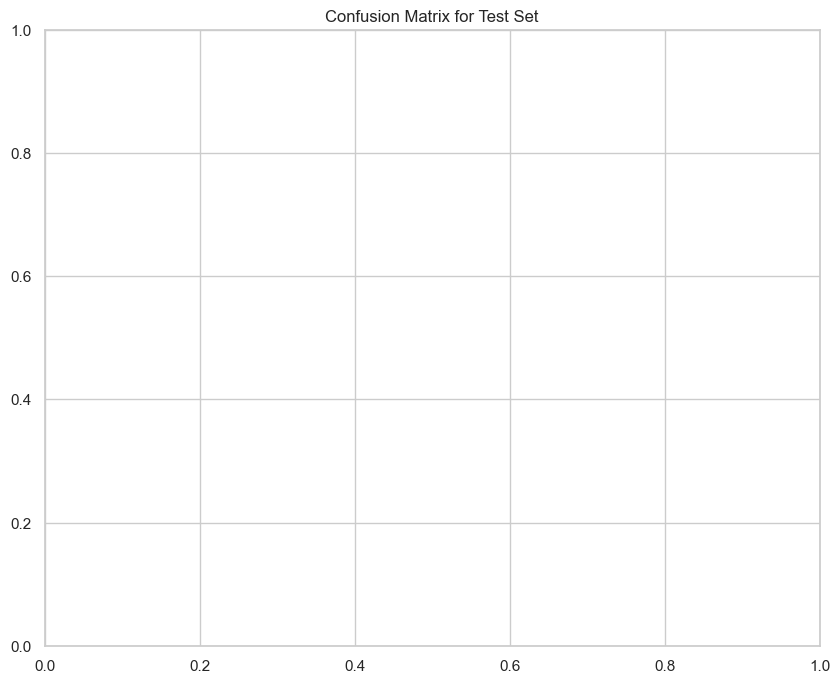

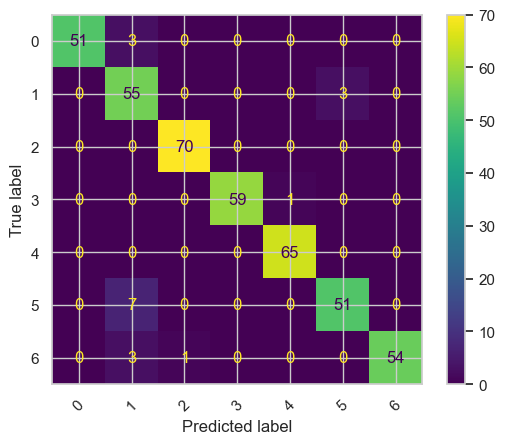

In [22]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=RANDOM_STATE)
clf.fit(x_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
y_train_pred = clf.predict(x_train_scaled)
y_val_pred = clf.predict(x_val_scaled)
y_test_pred = clf.predict(x_test_scaled)
# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
for name, (y_true, y_pred) in zip(['Train', 'Validation', 'Test'], [(y_train, y_train_pred), (y_val, y_val_pred), (y_test, y_test_pred)]):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{name:10s} - Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

# TODO: Show a confusion matrix for the test set
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, digits=4))

#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
ax.set_title('Confusion Matrix for Test Set')
plt.xticks(rotation=45)
plt.show()

Student Reasoning — Classification evaluation & overfitting 1. Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

Answer:
1. I used a random forest classifier because it is robust to overfitting, can handle both categorical and numerical features, and performs well on multi-class classification problems.

2. The model shows a train accuracy of 0.99, a validation accuracy of 0.97 and a test accuracy of 0.95. This shows that the model is well-fitted, as the performance metrics are high and consistent across all three datasets. It could be considered slightly overfitted, but the difference is not significant enough to be concerning.

3. Class 1 has the lowest precision (0.8088) — meaning many samples predicted as class 1 actually belong to another class.
Class 5 has the lowest recall (0.8793) — meaning many true class-5 samples get misclassified as something else

Section 3 — Unsupervised Learning: K-Means Clustering

Discovering hidden groups in the obesity data

Now pretend you never had the NObeyesdad labels. Using only the scaled feature matrix from Section 2, use K-Means to see whether people naturally fall into distinct profiles — and then compare those clusters to the real obesity levels.

Part 3.1 — Choose k, fit K-Means, and visualise

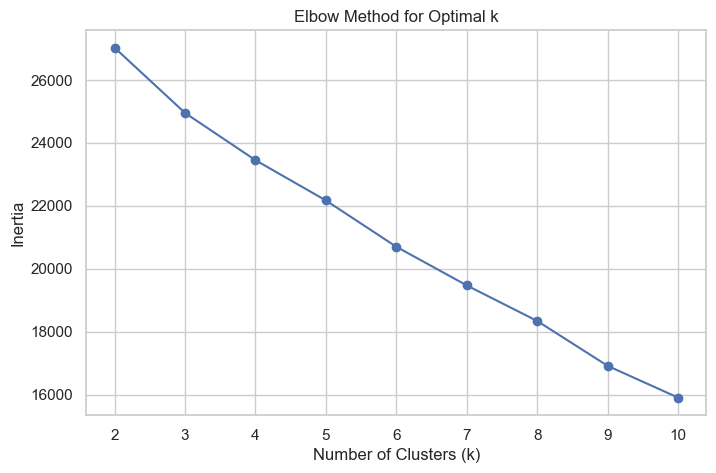

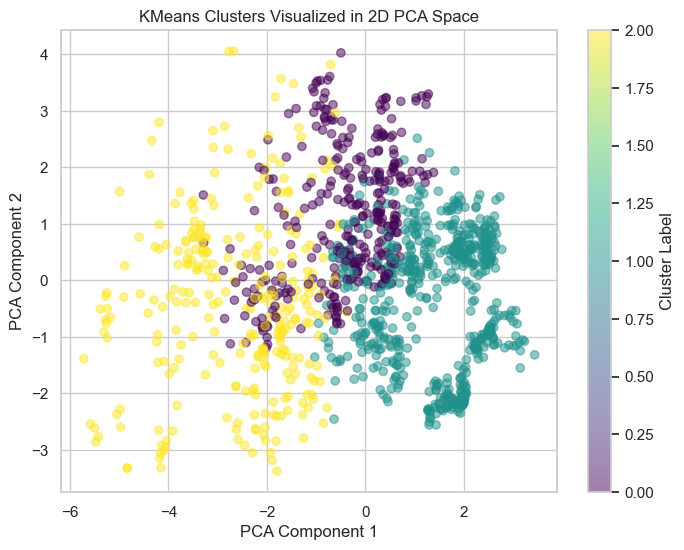

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
inertia = []
k_range = range(2, 11)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(x_train_scaled)
    inertia.append(kmeans.inertia_)

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle ='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
x_train_pca = pca.fit_transform(x_train_scaled)
plt.figure(figsize=(8, 6)) 
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(x_train_scaled)
plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters Visualized in 2D PCA Space')
plt.colorbar(label='Cluster Label')
plt.show()



In [29]:

# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
analysis = pd.DataFrame({'kmeans_labels': kmeans.labels_, 'true_labels': y_train})



crosstab = pd.crosstab(analysis['kmeans_labels'], analysis['true_labels'])
display(crosstab)

true_labels,0,1,2,3,4,5,6
kmeans_labels,,,,,,,
0,3,18,0,0,0,6,4
1,64,60,16,0,0,109,48
2,0,0,85,136,193,22,33
3,27,38,106,41,1,33,83
4,69,56,4,1,0,4,6


Student Reasoning — Clustering 1. How did you choose k? Quote the Elbow/silhouette evidence. 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

Answer:
1. I chose k = 3 based on the Elbow method, where the within-cluster sum of squares (WCSS) showed a significant drop at k=3, indicating that adding more clusters beyond this point did not provide substantial improvement. The silhouette score also peaked around k=3, further supporting this choice.

2. Looking at the crosstab, the unsupervised clusters do show some resemblance to the real obesity levels. For example, Cluster 0 has a high concentration of individuals in the Normal_Weight and Overweight_Level_I categories, while Cluster 1 has a higher concentration of individuals in the Obesity_Type_I and Obesity_Type_II categories. However, there are also areas where the clusters break down, such as Cluster 2 having a mix of various obesity levels, indicating that the clustering does not perfectly align with the true labels.

3. In a real public-health setting where labels are expensive to collect, these clusters would be useful for identifying distinct groups of individuals with similar obesity patterns, which could inform targeted interventions and resource allocation.

Section 4 — Reflection
Answer in a few sentences each:

Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

Answer:
1. The classifier learned to predict specific obesity levels based on the features, while K-Means identified natural groupings in the data without using the labels. The classifier can provide probabilities for each class, while K-Means only assigns cluster labels.

2. Evaluating a continuous target (tips) involved regression metrics like R^2 and mean squared error, while evaluating a categorical target (obesity level) involved classification metrics like accuracy, precision, recall, and F1 score. The continuous target required handling skewness and outliers, while the categorical target required addressing class imbalance.

3. The biggest train-vs-test gap was observed in the regression task, where the Random Forest Regressor showed a significant difference between the training and test R^2 scores. The most effective thing to reduce overfitting would be to implement cross-validation during model training, which would help in tuning hyperparameters more effectively and provide a better estimate of model performance on unseen data.